## PART 1 — Import Dataset & Exploratory Data Analysis (EDA)

### Step 1 Install Required Libraries

In [1]:
!pip -q install openpyxl
!pip -q install openmeteo-requests requests-cache retry-requests
!pip -q install xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\allyv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\allyv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\allyv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Step 2 Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

### Step 3 Read Dataset

In [3]:
df = pd.read_excel("DATALOG.CSV.xlsx")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


### Step 4 Rename Columns & Header Data

In [4]:
df.columns = [
    "Date",
    "Time",
    "IndoorTemp",
    "IndoorHumidity"
]

df.head()

,Date,Time,IndoorTemp,IndoorHumidity
0,2026-06-21,01:18:24,30.8,72.3
1,2026-06-21,01:18:26,30.8,72.4
2,2026-06-21,01:18:28,30.8,72.4
3,2026-06-21,01:18:30,30.8,72.4
4,2026-06-21,01:18:32,30.8,72.4


### Step 5 Create Datetime

In [5]:
df["Datetime"] = pd.to_datetime(
    df["Date"].astype(str)
    + " "
    + df["Time"].astype(str)
)
df = df.sort_values("Datetime")
df = df.reset_index(drop=True)
df.drop(columns=["Date", "Time"], inplace=True)

### Step 6 Extract Time Features

In [6]:
df["Hour"] = df["Datetime"].dt.hour
df["DayName"] = df["Datetime"].dt.day_name()
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["Weekend"] = (df["DayOfWeek"] >= 5).astype(int)

### Step 7 Rearrange Column Order

In [7]:
df = df[
    [
        "Datetime",
        "Hour",
        "DayName",
        "Weekend",
        "DayOfWeek",
        "IndoorTemp",
        "IndoorHumidity"
    ]
]

### Step 8 Dataset Information

In [8]:
print("Dataset Shape")
print(df.shape)
print("\n")

print("Dataset Info")
df.info()
print("\n")

print("Missing Values")
display(df.isnull().sum())
print("\n")

print("Duplicate Rows")
print(df.duplicated().sum())
print("\n")

print("Statistical Summary")
display(df.describe())

Dataset Shape
(10257, 7)


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10257 entries, 0 to 10256
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Datetime        10257 non-null  datetime64[ns]
 1   Hour            10257 non-null  int32         
 2   DayName         10257 non-null  object        
 3   Weekend         10257 non-null  int64         
 4   DayOfWeek       10257 non-null  int32         
 5   IndoorTemp      10257 non-null  float64       
 6   IndoorHumidity  10257 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(2), int64(1), object(1)
memory usage: 480.9+ KB


Missing Values


Datetime          0
Hour              0
DayName           0
Weekend           0
DayOfWeek         0
IndoorTemp        0
IndoorHumidity    0
dtype: int64



Duplicate Rows
0


Statistical Summary


,Datetime,Hour,Weekend,DayOfWeek,IndoorTemp,IndoorHumidity
count,10257,10257.000000,10257.000000,10257.000000,10257.000000,10257.000000
mean,2026-06-25 23:45:25.022716160,11.456956,0.286731,2.983328,28.292473,70.694150
min,2026-06-21 01:18:24,0.000000,0.000000,0.000000,18.600000,58.400000
25%,2026-06-24 05:11:58,5.000000,0.000000,1.000000,24.600000,66.100000
50%,2026-06-25 23:56:46,12.000000,0.000000,3.000000,30.000000,70.600000
75%,2026-06-27 18:41:39,17.000000,1.000000,5.000000,31.900000,75.300000
max,2026-06-29 13:26:36,23.000000,1.000000,6.000000,34.700000,88.600000
std,NaN,6.901237,0.452257,2.021871,4.564227,5.653743


### Step 9 Basic Visualization

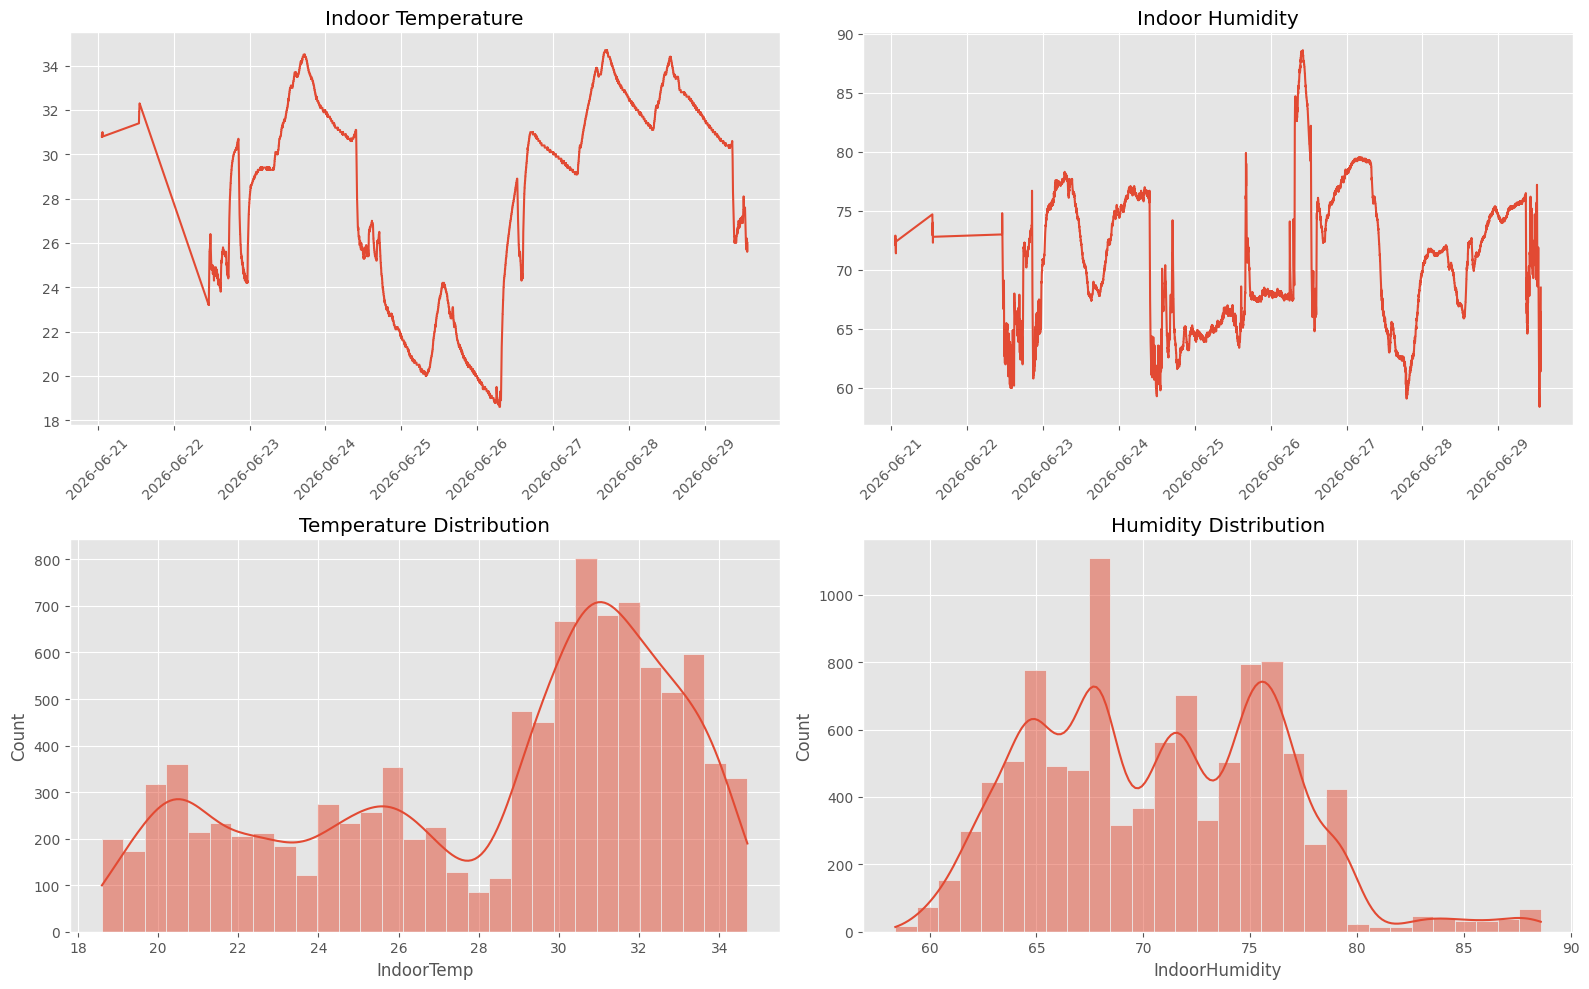

In [9]:
fig, ax = plt.subplots(2,2, figsize=(16,10))

# Indoor Temperature
ax[0,0].plot(
    df["Datetime"],
    df["IndoorTemp"]
)
ax[0,0].set_title("Indoor Temperature")
ax[0,0].tick_params(axis='x', rotation=45)

# Indoor Humidity
ax[0,1].plot(
    df["Datetime"],
    df["IndoorHumidity"]
)
ax[0,1].set_title("Indoor Humidity")
ax[0,1].tick_params(axis='x', rotation=45)

# Temperature Histogram
sns.histplot(
    df["IndoorTemp"],
    bins=30,
    kde=True,
    ax=ax[1,0]
)
ax[1,0].set_title("Temperature Distribution")

# Humidity Histogram
sns.histplot(
    df["IndoorHumidity"],
    bins=30,
    kde=True,
    ax=ax[1,1]
)
ax[1,1].set_title("Humidity Distribution")

plt.tight_layout()
plt.show()

### Step 10 Statistical Visualization

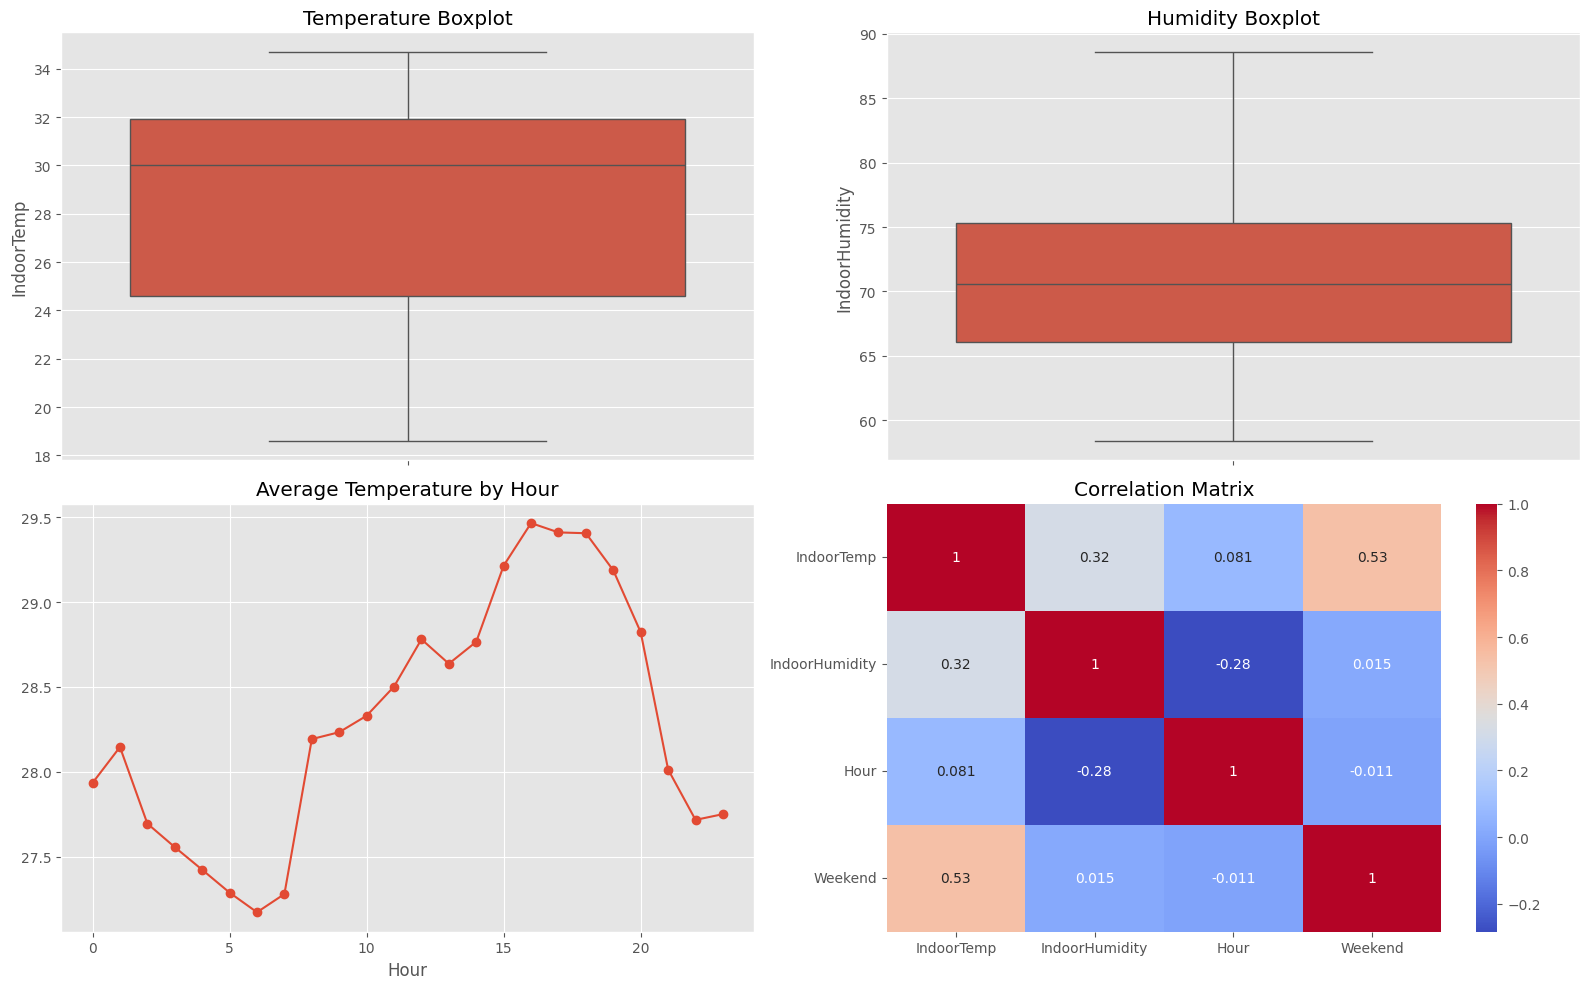

In [10]:
fig, ax = plt.subplots(2,2, figsize=(16,10))

# Temperature Boxplot
sns.boxplot(
    y=df["IndoorTemp"],
    ax=ax[0,0]
)
ax[0,0].set_title("Temperature Boxplot")

# Humidity Boxplot
sns.boxplot(
    y=df["IndoorHumidity"],
    ax=ax[0,1]
)
ax[0,1].set_title("Humidity Boxplot")

# Hourly Average Temperature
df.groupby("Hour")["IndoorTemp"].mean().plot(
    marker="o",
    ax=ax[1,0]
)
ax[1,0].set_title("Average Temperature by Hour")

# Correlation Matrix
corr = df[[
    "IndoorTemp",
    "IndoorHumidity",
    "Hour",
    "Weekend"
]].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    ax=ax[1,1]
)
ax[1,1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

### Step 11 Save Clean Dataset

In [11]:
df.to_csv(
    "Clean_Dataset.csv",
    index=False
)
print("Clean Dataset Saved Successfully!")

Clean Dataset Saved Successfully!


## PART 2 — Historical Weather Integration

### Step 1 Import Weather Libraries

In [12]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

### Step 2 Setup Open-Meteo (Weather API)

In [13]:
cache_session = requests_cache.CachedSession(
    ".cache",
    expire_after=3600
)

retry_session = retry(
    cache_session,
    retries=5,
    backoff_factor=0.2
)

client = openmeteo_requests.Client(
    session=retry_session
)

LATITUDE = 3.1728929615253114
LONGITUDE = 101.71978264862534

### Step 3 Get Date Range

In [14]:
start_date = df["Datetime"].min().strftime("%Y-%m-%d")
end_date = df["Datetime"].max().strftime("%Y-%m-%d")
print(start_date)
print(end_date)

2026-06-21
2026-06-29


### Step 4 Download Weather

In [15]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude":LATITUDE,
    "longitude":LONGITUDE,
    "start_date":start_date,
    "end_date":end_date,
    "hourly":[
        "temperature_2m",
        "relative_humidity_2m",
        "rain",
        "cloud_cover",
        "wind_speed_10m"
    ],
    "timezone":"Asia/Kuala_Lumpur"
}

response = client.weather_api(
    url,
    params=params
)[0]

### Step 5 Convert Weather to DataFrame

In [16]:
hourly = response.Hourly()
weather = pd.DataFrame({
    "Datetime":
    pd.date_range(
        start=pd.to_datetime(
            hourly.Time(),
            unit="s"
        ),
        end=pd.to_datetime(
            hourly.TimeEnd(),
            unit="s"
        ),
        freq=pd.Timedelta(
            seconds=hourly.Interval()
        ),
        inclusive="left"
    ),
    "OutdoorTemp":
    hourly.Variables(0).ValuesAsNumpy(),
    "OutdoorHumidity":
    hourly.Variables(1).ValuesAsNumpy(),
    "Rain":
    hourly.Variables(2).ValuesAsNumpy(),
    "CloudCover":
    hourly.Variables(3).ValuesAsNumpy(),
    "WindSpeed":
    hourly.Variables(4).ValuesAsNumpy()
})

weather.head()

,Datetime,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed
0,2026-06-20 16:00:00,25.049999,95.903397,0.2,90.0,6.519877
1,2026-06-20 17:00:00,25.250000,90.047913,0.0,95.0,7.059122
2,2026-06-20 18:00:00,25.750000,95.924232,0.0,73.0,1.405845
3,2026-06-20 19:00:00,25.450001,94.775391,0.0,80.0,3.864763
4,2026-06-20 20:00:00,24.700001,96.470406,0.3,94.0,4.680000


### Step 6 Time Interpolation

In [17]:
weather["Datetime"] = pd.to_datetime(weather["Datetime"])
weather = weather.set_index("Datetime")
weather = weather.resample("1min").interpolate()
weather = weather.reset_index()

### Step 7 Merge

In [18]:
df = pd.merge_asof(
    df.sort_values("Datetime"),
    weather.sort_values("Datetime"),
    on="Datetime",
    direction="nearest"
)

### Step 8 Check Missing Values

In [19]:
display(
    df[[
        "OutdoorTemp",
        "OutdoorHumidity",
        "Rain",
        "CloudCover",
        "WindSpeed"
    ]].isnull().sum()
)

OutdoorTemp        0
OutdoorHumidity    0
Rain               0
CloudCover         0
WindSpeed          0
dtype: int64

### Step 9 Dataset Preview

In [20]:
display(df.head())

,Datetime,Hour,DayName,Weekend,DayOfWeek,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed
0,2026-06-21 01:18:24,1,Sunday,1,6,30.8,72.3,27.595001,83.465576,0.0,88.199997,2.199785
1,2026-06-21 01:18:26,1,Sunday,1,6,30.8,72.4,27.595001,83.465576,0.0,88.199997,2.199785
2,2026-06-21 01:18:28,1,Sunday,1,6,30.8,72.4,27.595001,83.465576,0.0,88.199997,2.199785
3,2026-06-21 01:18:30,1,Sunday,1,6,30.8,72.4,27.595001,83.465576,0.0,88.199997,2.199785
4,2026-06-21 01:18:32,1,Sunday,1,6,30.8,72.4,27.630835,83.283875,0.0,87.933334,2.185981


### Step 10 Weather, Temperature and Humidity Visualization

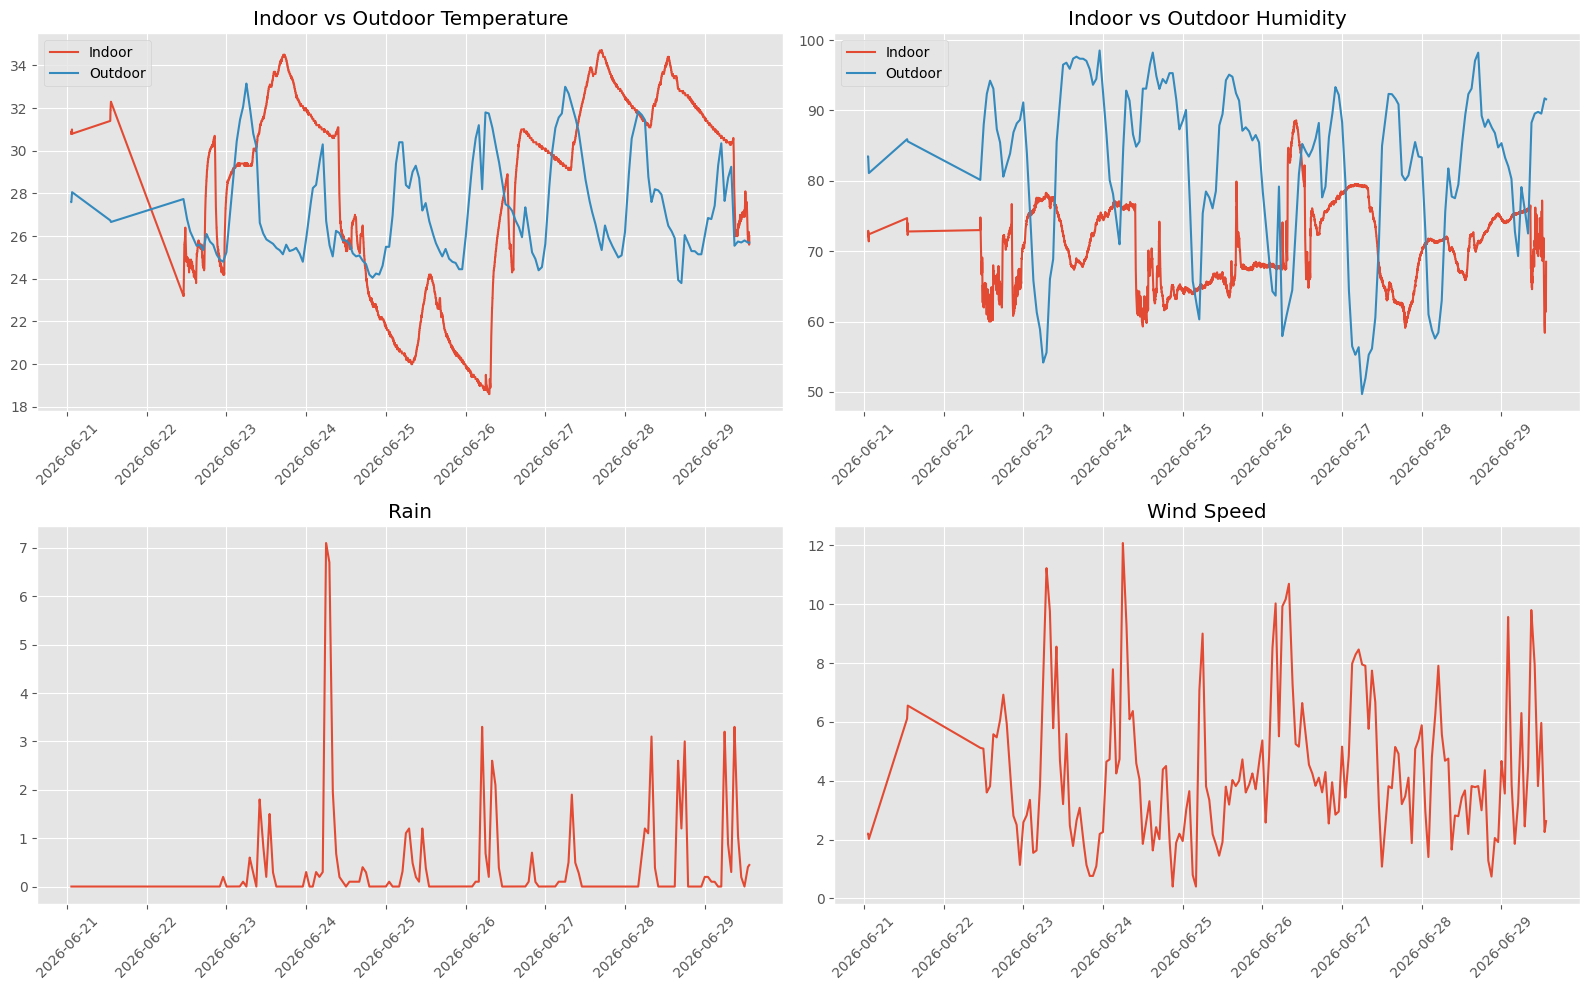

In [21]:
fig, ax = plt.subplots(2,2, figsize=(16,10))

# Indoor vs Outdoor Temperature
ax[0,0].plot(
    df["Datetime"],
    df["IndoorTemp"],
    label="Indoor"
)
ax[0,0].plot(
    df["Datetime"],
    df["OutdoorTemp"],
    label="Outdoor"
)
ax[0,0].legend()
ax[0,0].set_title("Indoor vs Outdoor Temperature")
ax[0,0].tick_params(axis='x', rotation=45)

# Indoor vs Outdoor Humidity
ax[0,1].plot(
    df["Datetime"],
    df["IndoorHumidity"],
    label="Indoor"
)
ax[0,1].plot(
    df["Datetime"],
    df["OutdoorHumidity"],
    label="Outdoor"
)
ax[0,1].legend()
ax[0,1].set_title("Indoor vs Outdoor Humidity")
ax[0,1].tick_params(axis='x', rotation=45)

# Rain
ax[1,0].plot(
    df["Datetime"],
    df["Rain"]
)
ax[1,0].set_title("Rain")
ax[1,0].tick_params(axis='x', rotation=45)

# Wind Speed
ax[1,1].plot(
    df["Datetime"],
    df["WindSpeed"]
)
ax[1,1].set_title("Wind Speed")
ax[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Step 11 Save Weather Dataset

In [22]:
df.to_csv(
    "Weather_Integrated_Dataset.csv",
    index=False
)
print("Weather data successfully integrated!")

Weather data successfully integrated!


## PART 3 — Cooling Confidence Score & Initial AC Label Generation

### Step 1 Feature Engineering

In [23]:
# Indoor vs Outdoor Temperature Difference
df["TempDifference"] = df["OutdoorTemp"] - df["IndoorTemp"]

# Indoor vs Outdoor Humidity Difference
df["HumidityDifference"] = df["OutdoorHumidity"] - df["IndoorHumidity"]

# Temperature Change
df["TempChange"] = df["IndoorTemp"].diff().fillna(0)

# Humidity Change
df["HumidityChange"] = df["IndoorHumidity"].diff().fillna(0)

# Outdoor temperature trend
df["OutdoorTempChange"] = df["OutdoorTemp"].diff().fillna(0)

# Weather Effect Score
def weather_effect(rain, cloud, outdoor_change):

    score = 1.0

    # Natural cooling due to rain
    if rain > 0:
        score -= 0.20

    # Heavy cloud cover
    if cloud > 80:
        score -= 0.15

    # Outdoor temperature dropping quickly
    if outdoor_change < -0.5:
        score -= 0.20

    return max(score, 0.40)

df["WeatherEffect"] = df.apply(
    lambda x: weather_effect(
        x["Rain"],
        x["CloudCover"],
        x["OutdoorTempChange"]
    ),
    axis=1
)

### Step 2 Normalize Features

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[[
    "TempDifference",
    "HumidityDifference"
]] = scaler.fit_transform(
    df[[
        "TempDifference",
        "HumidityDifference"
    ]]
)

### Step 3 Create Cooling Trend Score

In [25]:
df["CoolingTrend"] = (
    (-df["TempChange"])
    +
    (-df["HumidityChange"])
)

In [26]:
df["CoolingTrend"] = MinMaxScaler().fit_transform(
    df[["CoolingTrend"]]
)

### Step 4 Office Hour Score

In [27]:
def office_score(day, hour):

    # Weekend
    if day in ["Saturday", "Sunday"]:
        return 0.10

    # Peak class / office hours
    elif 9 <= hour <= 12:
        return 1.00

    elif 14 <= hour <= 17:
        return 1.00

    # Early morning
    elif 8 <= hour < 9:
        return 0.70

    # Lunch hour
    elif 12 < hour < 14:
        return 0.70

    # Evening
    elif 17 < hour <= 19:
        return 0.50

    # Night
    else:
        return 0.20
    
df["OfficeScore"] = df.apply(
    lambda x: office_score(x["DayName"], x["Hour"]),
    axis=1
)

### Step 5 Cooling Confidence Score

In [28]:
TEMP_WEIGHT = 0.30
TREND_WEIGHT = 0.25
HUMIDITY_WEIGHT = 0.15
OFFICE_WEIGHT = 0.15
WEATHER_WEIGHT = 0.15

In [29]:
df["CoolingConfidence"] = (
    TEMP_WEIGHT * df["TempDifference"]
    +
    TREND_WEIGHT * df["CoolingTrend"]
    +
    HUMIDITY_WEIGHT * df["HumidityDifference"]
    +
    OFFICE_WEIGHT * df["OfficeScore"]
    +
    WEATHER_WEIGHT * df["WeatherEffect"]
)

### Step 6 Generate Initial Labels

In [30]:
THRESHOLD = 0.60
df["AC_Status"] = (
    df["CoolingConfidence"]
    >= THRESHOLD
).astype(int)

### Step 7 Show Probability

In [31]:
df["AC_Probability"] = (
    df["CoolingConfidence"]
    *100
).round(1)

### Step 8 Visualization

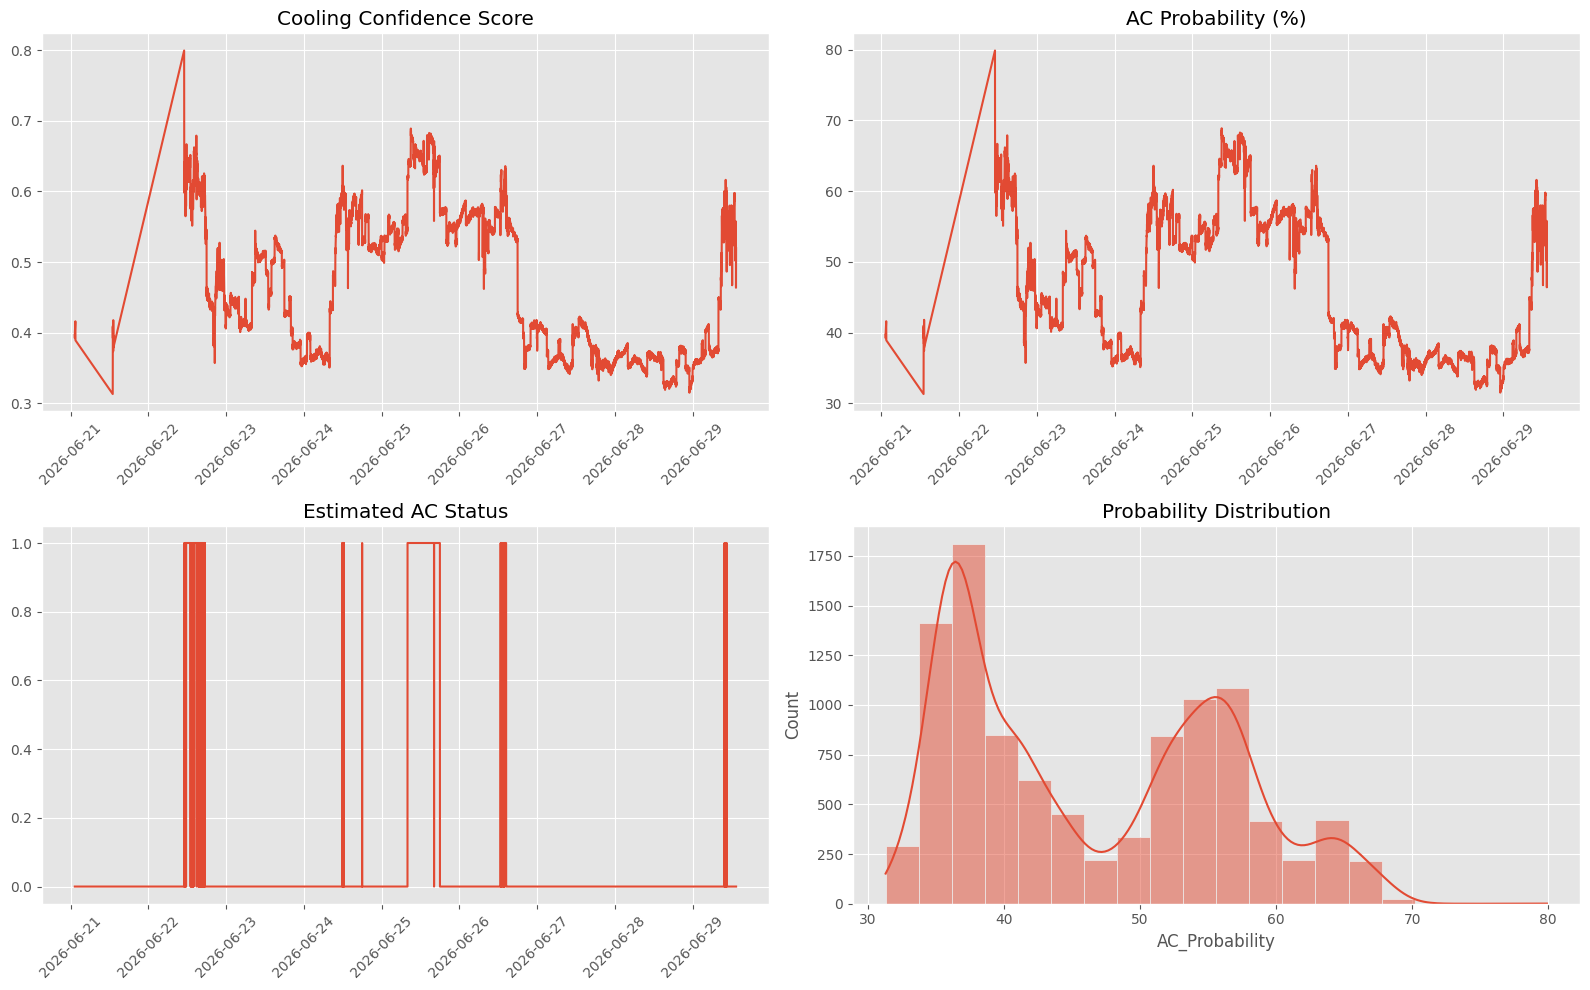

In [32]:
fig, ax = plt.subplots(2,2, figsize=(16,10))

# Cooling Confidence
ax[0,0].plot(
    df["Datetime"],
    df["CoolingConfidence"]
)
ax[0,0].set_title("Cooling Confidence Score")
ax[0,0].tick_params(axis='x', rotation=45)

# Probability
ax[0,1].plot(
    df["Datetime"],
    df["AC_Probability"]
)
ax[0,1].set_title("AC Probability (%)")
ax[0,1].tick_params(axis='x', rotation=45)

# AC Status
ax[1,0].step(
    df["Datetime"],
    df["AC_Status"],
    where="post"
)
ax[1,0].set_title("Estimated AC Status")
ax[1,0].tick_params(axis='x', rotation=45)

# Probability Distribution
sns.histplot(
    df["AC_Probability"],
    bins=20,
    kde=True,
    ax=ax[1,1]
)
ax[1,1].set_title("Probability Distribution")

plt.tight_layout()
plt.show()

### Step 9 Save Final Dataset

In [33]:
df.to_csv(
    "AI_Training_Dataset.csv",
    index=False
)
print("AI Training Dataset Saved!")

AI Training Dataset Saved!


## PART 4 — AI Model Training

### Step 1 Import Machine Learning Libraries

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
)

### Step 2 Select Features

In [35]:
features = [
    # Time Features
    "Hour",
    "DayOfWeek",
    "Weekend",
    # Indoor Sensor
    "IndoorTemp",
    "IndoorHumidity",
    # Outdoor Weather
    "OutdoorTemp",
    "OutdoorHumidity",
    "Rain",
    "CloudCover",
    "WindSpeed",
    # Thermal Dynamics
    "TempDifference",
    "HumidityDifference",
    "TempChange",
    "HumidityChange",
    "OutdoorTempChange"
]

X = df[features]
y = df["AC_Status"]
print("Number of Features:", len(features))
print(features)

Number of Features: 15
['Hour', 'DayOfWeek', 'Weekend', 'IndoorTemp', 'IndoorHumidity', 'OutdoorTemp', 'OutdoorHumidity', 'Rain', 'CloudCover', 'WindSpeed', 'TempDifference', 'HumidityDifference', 'TempChange', 'HumidityChange', 'OutdoorTempChange']


### Step 3 Train/Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 8205
Testing Samples  : 2052


### Step 4 Train Random Forest

In [37]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

### Step 5 Train XGBoost

In [38]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

### Step 6 Evaluation Function

In [39]:
def evaluate_model(name, y_true, pred, prob):
    print("="*60)
    print(name)
    print("="*60)
    print(f"Accuracy : {accuracy_score(y_true,pred):.4f}")
    print(f"Precision: {precision_score(y_true,pred):.4f}")
    print(f"Recall   : {recall_score(y_true,pred):.4f}")
    print(f"F1 Score : {f1_score(y_true,pred):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_true,prob):.4f}")
    print("\nClassification Report\n")
    print(classification_report(y_true,pred))

In [40]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

Random Forest
Accuracy : 0.9956
Precision: 0.9788
Recall   : 0.9737
F1 Score : 0.9763
ROC AUC  : 0.9997

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1862
           1       0.98      0.97      0.98       190

    accuracy                           1.00      2052
   macro avg       0.99      0.99      0.99      2052
weighted avg       1.00      1.00      1.00      2052

XGBoost
Accuracy : 0.9946
Precision: 0.9838
Recall   : 0.9579
F1 Score : 0.9707
ROC AUC  : 0.9997

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1862
           1       0.98      0.96      0.97       190

    accuracy                           0.99      2052
   macro avg       0.99      0.98      0.98      2052
weighted avg       0.99      0.99      0.99      2052



### Step 7 Model Comparison

In [41]:
results = pd.DataFrame({
    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred)
    ],

    "Precision":[
        precision_score(y_test,rf_pred),
        precision_score(y_test,xgb_pred)
    ],

    "Recall":[
        recall_score(y_test,rf_pred),
        recall_score(y_test,xgb_pred)
    ],

    "F1 Score":[
        f1_score(y_test,rf_pred),
        f1_score(y_test,xgb_pred)
    ],

    "ROC AUC":[
        roc_auc_score(y_test,rf_prob),
        roc_auc_score(y_test,xgb_prob)
    ]
})
display(results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.9956,0.9788,0.9737,0.9763,0.9997
1,XGBoost,0.9946,0.9838,0.9579,0.9707,0.9997


### Step 8 Combined Visualization

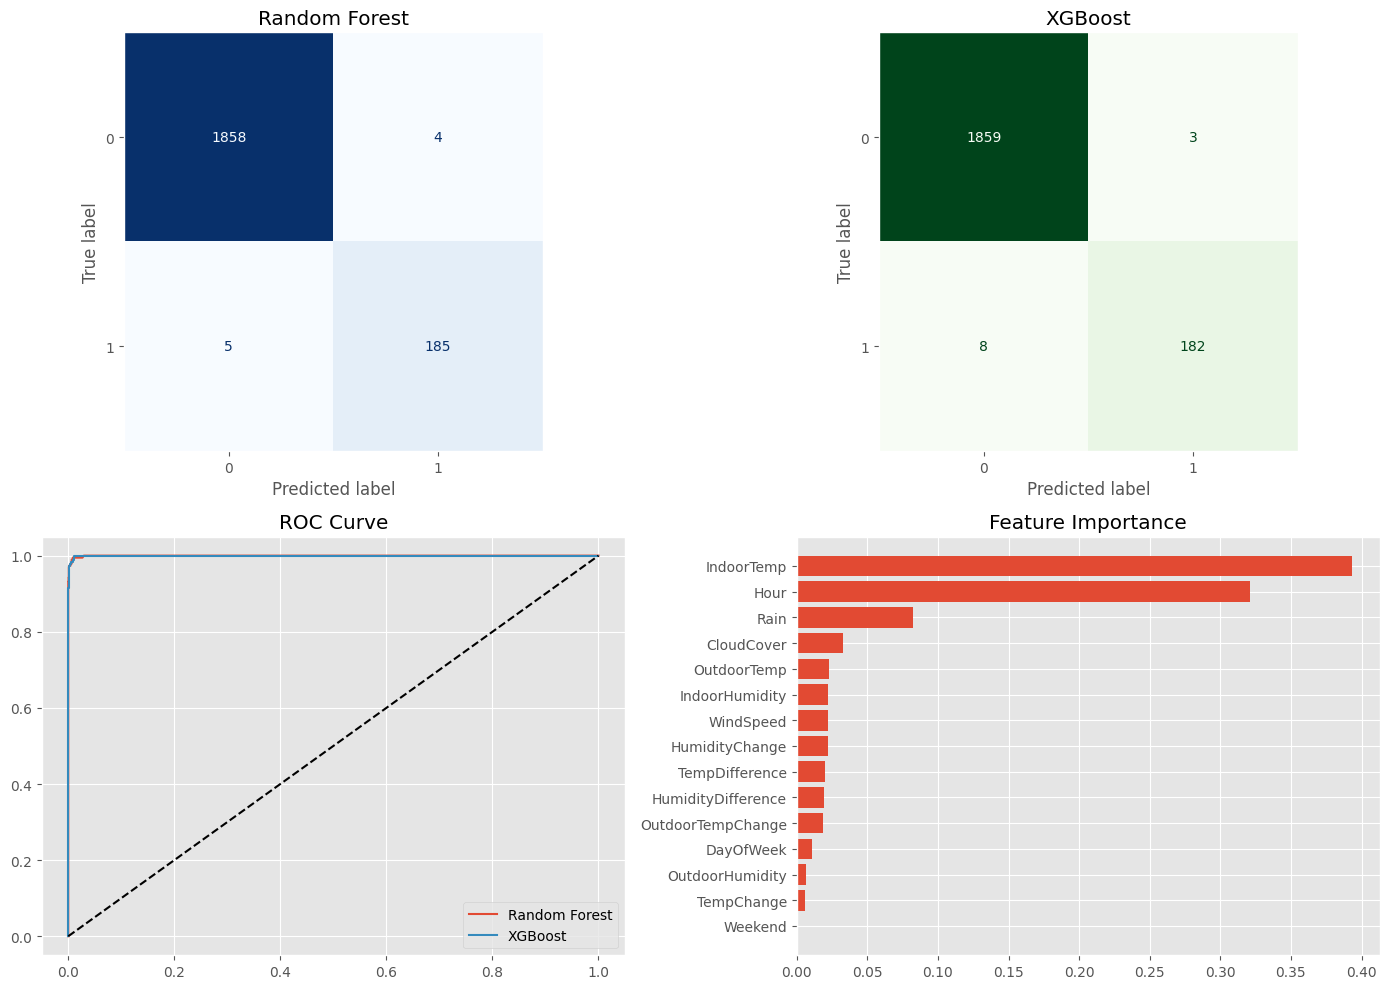

In [42]:
fig, ax = plt.subplots(2,2, figsize=(14,10))

# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    ax=ax[0,0],
    cmap="Blues",
    colorbar=False,
    values_format="d"
)
ax[0,0].set_title("Random Forest")
ax[0,0].grid(False)

# XGBoost Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    ax=ax[0,1],
    cmap="Greens",
    colorbar=False,
    values_format="d"
)
ax[0,1].set_title("XGBoost")
ax[0,1].grid(False)

# ROC Curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

ax[1,0].plot(rf_fpr, rf_tpr, label="Random Forest")
ax[1,0].plot(xgb_fpr, xgb_tpr, label="XGBoost")
ax[1,0].plot([0,1],[0,1],'k--')
ax[1,0].set_title("ROC Curve")
ax[1,0].legend()

# Feature Importance
importance = pd.DataFrame({
    "Feature":features,
    "Importance":xgb.feature_importances_
}).sort_values(
    "Importance",
    ascending=True
)
ax[1,1].barh(
    importance["Feature"],
    importance["Importance"]
)
ax[1,1].set_title("Feature Importance")

plt.tight_layout()
plt.show()

### Step 9 Cross Validation

In [43]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("5-Fold Cross Validation")
for i, score in enumerate(scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"Average Accuracy : {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

5-Fold Cross Validation
Fold 1: 0.9513
Fold 2: 0.8285
Fold 3: 0.8089
Fold 4: 0.9790
Fold 5: 0.9157
Average Accuracy : 0.8967
Standard Deviation: 0.0671


### Step 10 Random Sample Prediction

In [44]:
prediction_result = X_test.copy()

prediction_result["Actual"] = y_test.values
prediction_result["Predicted"] = xgb_pred
prediction_result["Probability"] = (xgb_prob * 100).round(2)

# Probability Interpretation
def interpret(prob):
    if prob >= 90:
        return "Very Likely ON"
    elif prob >= 70:
        return "Likely ON"
    elif prob >= 40:
        return "Uncertain"
    else:
        return "Likely OFF"

prediction_result["Interpretation"] = prediction_result["Probability"].apply(interpret)
prediction_result["Actual"] = prediction_result["Actual"].replace({
    1: "ON",
    0: "OFF"
})
prediction_result["Predicted"] = prediction_result["Predicted"].replace({
    1: "ON",
    0: "OFF"
})

# Randomly display 10 prediction examples
prediction_result = prediction_result.sample(
    n=min(10, len(prediction_result)),
    random_state=42
).reset_index(drop=True)

display(
    prediction_result[
        [
            "IndoorTemp",
            "IndoorHumidity",
            "OutdoorTemp",
            "OutdoorHumidity",
            "Actual",
            "Predicted",
            "Probability",
            "Interpretation"
        ]
    ]
)

,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Actual,Predicted,Probability,Interpretation
0,32.4,66.9,29.318333,77.106285,OFF,OFF,0.000000,Likely OFF
1,29.4,79.5,31.643333,55.786110,OFF,OFF,0.020000,Likely OFF
2,22.3,66.1,27.587502,85.488823,ON,ON,99.949997,Very Likely ON
3,32.6,69.5,25.695000,83.387955,OFF,OFF,0.000000,Likely OFF
4,32.4,72.8,25.320833,94.078766,OFF,OFF,0.000000,Likely OFF
5,29.3,77.8,31.891666,57.316269,OFF,OFF,0.010000,Likely OFF
6,25.7,87.3,30.025000,67.515579,OFF,OFF,0.040000,Likely OFF
7,31.1,74.4,27.000000,81.529602,OFF,OFF,0.000000,Likely OFF
8,31.8,75.3,25.150000,85.061623,OFF,OFF,0.000000,Likely OFF
9,29.3,79.4,32.375000,53.030037,OFF,OFF,0.000000,Likely OFF


### Step 11 Save Best Model

In [45]:
import joblib

joblib.dump(rf, "SmartHVAC_RandomForest_Model.pkl")
joblib.dump(features, "feature_columns.pkl")

['feature_columns.pkl']